<a href="https://colab.research.google.com/github/Zandersan/ml_study/blob/deteccao_facial/deteccao_facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Instalar bibliotecas necessárias
!pip install mtcnn tensorflow opencv-python matplotlib kagglehub

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import kagglehub

In [2]:
# 2. Baixar dataset do KaggleHub
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")
print("Dataset baixado em:", path)

Dataset baixado em: /kaggle/input/celebrity-face-image-dataset


In [3]:
# 3. Definir caminho das imagens
dataset_path = os.path.join(path, "Celebrity Faces Dataset")
print("Dataset path:", dataset_path)

Dataset path: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset


In [4]:
# 4. Carregar imagens e labels
classes = os.listdir(dataset_path)
print(f"{len(classes)} classes encontradas: {classes}")

X = []
y = []

print("Carregando imagens...")
for idx, pessoa in enumerate(classes):
    pasta = os.path.join(dataset_path, pessoa)
    for file in os.listdir(pasta):
        img_path = os.path.join(pasta, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        X.append(img)
        y.append(idx)

X = np.array(X) / 255.0
y = to_categorical(y, num_classes=len(classes))

print(f"Total de imagens carregadas: {len(X)}")

17 classes encontradas: ['Angelina Jolie', 'Sandra Bullock', 'Nicole Kidman', 'Megan Fox', 'Johnny Depp', 'Natalie Portman', 'Tom Cruise', 'Brad Pitt', 'Jennifer Lawrence', 'Tom Hanks', 'Scarlett Johansson', 'Kate Winslet', 'Will Smith', 'Robert Downey Jr', 'Denzel Washington', 'Hugh Jackman', 'Leonardo DiCaprio']
Carregando imagens...
Total de imagens carregadas: 1800


In [5]:
# 5. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Treino: {len(X_train)} imagens | Teste: {len(X_test)} imagens")

Treino: 1440 imagens | Teste: 360 imagens


In [6]:
# 6. Criar modelo CNN para classificação facial
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,355,281 (16.61 MB)

 Trainable params: 4,355,281 (16.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 7. Treinar modelo
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=16)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.0675 - loss: 2.9358 - val_accuracy: 0.1528 - val_loss: 2.7724
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.1553 - loss: 2.6491 - val_accuracy: 0.2028 - val_loss: 2.5763
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.2555 - loss: 2.3228 - val_accuracy: 0.2139 - val_loss: 2.4986
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.4000 - loss: 1.8896 - val_accuracy: 0.2250 - val_loss: 2.4457
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 228ms/step - accuracy: 0.5325 - loss: 1.4585 - val_accuracy: 0.2389 - val_loss: 2.6080
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.6839 - loss: 1.0695 - val_accuracy: 0.2472 - val_loss: 2.7932
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - accuracy: 0.7466 - loss: 0.7689 - val_accuracy: 0.2778 - val_loss: 3.0051
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.8250 - loss: 0.5973 - val_accu

In [8]:
# 8. Função para detecção + reconhecimento de múltiplas faces em imagens novas
detector = MTCNN()

def reconhecer_faces(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)
    for res in faces:
        x, y, w, h = res['box']
        face = cv2.resize(img_rgb[y:y+h, x:x+w], (100, 100)) / 255.0
        face = np.expand_dims(face, axis=0)
        pred = model.predict(face)
        classe = np.argmax(pred)
        conf = np.max(pred)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img_rgb, f"{classes[classe]} ({conf*100:.1f}%)", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)
    plt.figure(figsize=(10,10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

Testando com imagem: /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/049_4d6df392.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


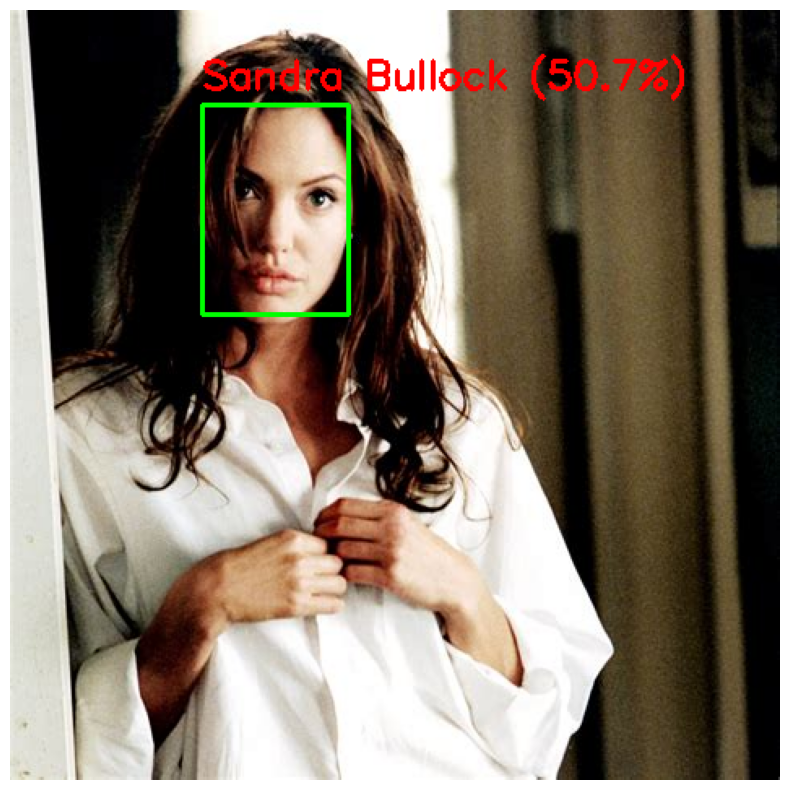

In [9]:
# 9. Testar com uma imagem do dataset (exemplo)
teste_img = os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])
print("Testando com imagem:", teste_img)
reconhecer_faces(teste_img)

Faça upload da imagem para teste:


Saving robert-downey-jr-scarlett-johansson-samuel-l-440nw-1172492q.jpg to robert-downey-jr-scarlett-johansson-samuel-l-440nw-1172492q (1).jpg
Testando imagem: robert-downey-jr-scarlett-johansson-samuel-l-440nw-1172492q (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


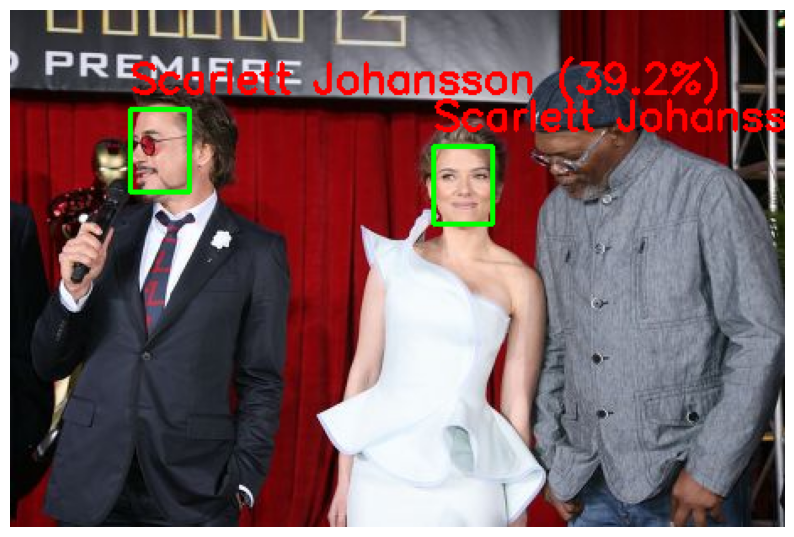

In [11]:
# 10. Upload e teste com imagem externa
from google.colab import files

# Upload de imagem para teste
print("Faça upload da imagem para teste:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"Testando imagem: {fn}")
    reconhecer_faces(fn)